<a href="https://colab.research.google.com/github/TR2Theo/simulasi-model-ising-2d/blob/main/komputasi_lsT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Menjalankan simulasi untuk T = 2.27...


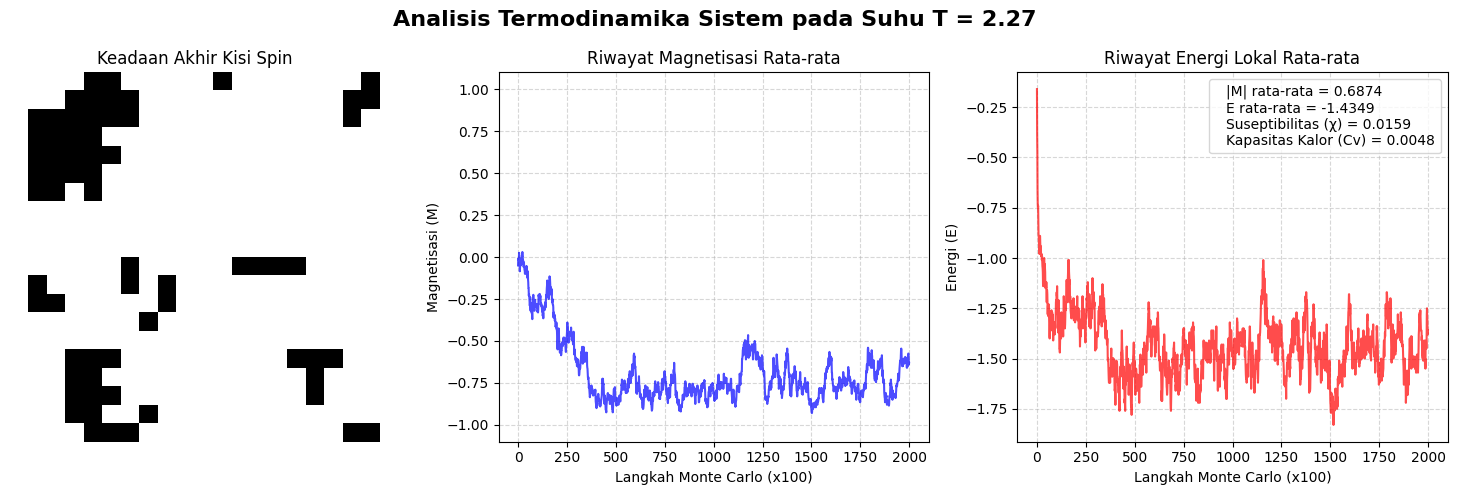

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

def hitung_energi_total(grid):
    """
    Menghitung energi total awal kisi dengan kondisi batas periodik.
    Menggunakan vektorisasi np.roll agar komputasi lebih cepat.
    """
    tetangga_atas = np.roll(grid, 1, axis=0)
    tetangga_bawah = np.roll(grid, -1, axis=0)
    tetangga_kiri = np.roll(grid, 1, axis=1)
    tetangga_kanan = np.roll(grid, -1, axis=1)

    jumlah_tetangga = tetangga_atas + tetangga_bawah + tetangga_kiri + tetangga_kanan

    # Dibagi 2 untuk mencegah perhitungan ganda antar pasangan tetangga
    energi_total = -np.sum(grid * jumlah_tetangga) / 2.0
    return energi_total

def metropolis_step(grid, T):
    """
    Satu langkah Metropolis yang mengembalikan matriks grid terbaru
    dan perubahan energi (jika diterima).
    """
    N = grid.shape[0]

    # Memilih koordinat spin secara acak
    x, y = random.randint(0, N-1), random.randint(0, N-1)

    # Menghitung jumlah spin tetangga (batas periodik modulo)
    s_neighbors = (
        grid[(x+1)%N, y] + grid[(x-1)%N, y] +
        grid[x, (y+1)%N] + grid[x, (y-1)%N]
    )

    # Menghitung potensi perubahan energi (Delta E)
    delta_E = 2 * grid[x, y] * s_neighbors
    dE_diterima = 0

    # Kriteria Metropolis
    if delta_E <= 0 or random.random() < np.exp(-delta_E / T):
        grid[x, y] *= -1 # Balikkan spin
        dE_diterima = delta_E # Catat perubahan energi yang masuk ke sistem

    return grid, dE_diterima

def run_simulation(N=20, temp=1.0, n_steps=200000):
    """
    Menjalankan simulasi dan merekam makrostate magnetisasi & energi secara efisien.
    """
    # Inisialisasi awal (Hot Start)
    grid = np.random.choice([-1, 1], size=(N, N))
    energi_sistem = hitung_energi_total(grid)

    magnetization_history = []
    energy_history = []

    for step in range(n_steps):
        grid, dE_diterima = metropolis_step(grid, temp)
        energi_sistem += dE_diterima # Update energi hanya berdasarkan dE

        # Pengambilan sampel setiap 100 langkah
        if step % 100 == 0:
            magnetization_history.append(np.mean(grid))
            energy_history.append(energi_sistem / (N**2)) # Energi rata-rata per spin

    return grid, magnetization_history, energy_history

def plot_studi_kasus(grid_size, T, n_steps):
    """
    Memproses satu kasus suhu, menghitung fluktuasi, dan menampilkan 3 plot berdampingan.
    """
    print(f"Menjalankan simulasi untuk T = {T}...")
    final_grid, M_history, E_history = run_simulation(N=grid_size, temp=T, n_steps=n_steps)

    # Konversi ke array NumPy untuk memudahkan perhitungan statistik
    M_array = np.array(M_history)
    E_array = np.array(E_history)

    # Menghitung Fluktuasi menggunakan variansi
    suseptibilitas = np.var(M_array) / T
    kapasitas_kalor = np.var(E_array) / (T**2)

    # Setup Visualisasi
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Analisis Termodinamika Sistem pada Suhu T = {T}', fontsize=16, fontweight='bold')

    # Plot 1: Keadaan Akhir Kisi (Domain Magnetik)
    ax_grid = axes[0]
    ax_grid.imshow(final_grid, cmap='binary', vmin=-1, vmax=1)
    ax_grid.set_title("Keadaan Akhir Kisi Spin")
    ax_grid.axis('off')

    # Plot 2: Riwayat Magnetisasi
    ax_mag = axes[1]
    ax_mag.plot(M_array, color='blue', alpha=0.7)
    ax_mag.set_title("Riwayat Magnetisasi Rata-rata")
    ax_mag.set_xlabel("Langkah Monte Carlo (x100)")
    ax_mag.set_ylabel("Magnetisasi (M)")
    ax_mag.set_ylim(-1.1, 1.1)
    ax_mag.grid(True, linestyle='--', alpha=0.5)

    # Plot 3: Riwayat Energi
    ax_e = axes[2]
    ax_e.plot(E_array, color='red', alpha=0.7)
    ax_e.set_title("Riwayat Energi Lokal Rata-rata")
    ax_e.set_xlabel("Langkah Monte Carlo (x100)")
    ax_e.set_ylabel("Energi (E)")
    ax_e.grid(True, linestyle='--', alpha=0.5)

    # Menempelkan nilai statistik di dalam plot energi sebagai legenda
    teks_statistik = (
        f'|M| rata-rata = {abs(np.mean(M_array)):.4f}\n'
        f'E rata-rata = {np.mean(E_array):.4f}\n'
        f'Suseptibilitas (\u03c7) = {suseptibilitas:.4f}\n'
        f'Kapasitas Kalor (Cv) = {kapasitas_kalor:.4f}'
    )
    teks_legenda = mpatches.Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='none')
    ax_e.legend([teks_legenda], [teks_statistik], loc='best', handlelength=0, fontsize=10)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Parameter Utama Simulasi
    grid_size = 20
    monte_carlo_steps = 200000

    # Daftar Suhu untuk 3 Studi Kasus (Feromagnetik, Kritis, Paramagnetik)
    suhu_studi_kasus = [2.27]

    # Eksekusi berurutan untuk setiap studi kasus
    for suhu in suhu_studi_kasus:
        plot_studi_kasus(grid_size, suhu, monte_carlo_steps)